# 24 — Retreat Arc Geometry: Re-Approach Prediction (NB24 v2 rebuild)

**REBUILD v2 (2026-04-08).** The original NB24 had fatal bugs: hardcoded 180px result bands, no scroll correction (mouse coordinates in viewport-space compared to AOIs in page-space), Fitts W denominator using fictional 180px constant, AOI center using viewport center 640 instead of content centerline ~432, and re-approach detection sorting by `dwell_ms` instead of entry timestamp. Every quantitative claim from the original was unreliable.

This rebuild:
- Uses `data_loader.interpolate_scroll` to map cursor coordinates from screen-space to page-space at every event
- Uses per-trial `result_band_tops` (from `extract_serp_results` + `doc_height` metadata) for AOI geometry
- Uses per-trial ad-boundary JSON for ground-truth ad heights (Fitts W per target)
- Uses content centerline (x ≈ 432, derived from ad boundary geometry x=162, width=540) not viewport center
- Stores `entry_t` on every arc, sorts re-approach detection by it
- Tracks participant ID for clustering acknowledgement

## Original hypothesis (REJECTED, see §5)

The original framing for this notebook was: cursor retreat is an *epistemic action* (Kirsh & Maglio, 1994) — moving the cursor far from a rejected result raises the motor cost of returning, encoding rejection confidence into physical space. Predicted:
1. Top ads (highest discrimination cost from NB20) would show the largest arcs
2. Long dwells would produce curvier retreats (uncertainty → motor cost)
3. Short retreats would predict re-approach because they didn't "lock in" the rejection

**The data do not support this framing.** Predictions 1 and 2 fail under participant clustering or are null. Prediction 3 holds but in a way that argues against the original mechanism. See §5 for the post-mortem and the surviving signal.

## What this rebuild actually finds

A reliable re-approach prediction signal: arc geometry features (arc ratio, max retreat distance, Fitts ID at max retreat) discriminate retreats that the user later returns to from retreats that stick. The pattern is **curved + close + low ID = "I'll be back"; straight + far + high ID = "I'm done."** This is a deliberation/commitment indicator, not a confidence-encoding mechanism. The cursor narrates the decision; it does not implement it.

**Caveats acknowledged up front:**
- Arcs come from 47 participants. Tests below treat arcs as independent observations; this inflates Type I error. A mixed-effects model is needed before any p value is publishable.
- Minimum direct-distance floor of 50px applied to arc ratio calculations to avoid jitter inflation.

In [1]:
import json
import sys
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from pathlib import Path
from bisect import bisect_right
from collections import defaultdict

# Use the canonical data primitives
sys.path.insert(0, '.')
from data_loader import (
    DATA_DIR, get_trial_ids, load_mouse_events, get_trial_meta,
    interpolate_scroll, result_band_tops, extract_serp_results,
    load_trial,
)
from episode_classifier import classify_trial_episodes

plt.rcParams.update({
    'figure.figsize': (14, 5), 'font.size': 12,
    'axes.titlesize': 14, 'axes.labelsize': 12,
    'figure.facecolor': 'white',
})

AD_DIR = DATA_DIR / 'ad-boundary-data'

# Content geometry — derived from ad boundary data, not viewport
# Ads at x=162, width=540 → content spans 162 to 702 → centerline 432
CONTENT_CX = 432

print(f"data_loader.DATA_DIR: {DATA_DIR}")
print(f"Trial ids: {len(get_trial_ids())}")


data_loader.DATA_DIR: /Users/andyed/Documents/dev/attentional-foraging/AdSERP/data
Trial ids: 2776


## 1. Extract retreat arcs (page-space, scroll-corrected)

For each trial:
1. Load mouse events with `load_mouse_events` (gives mousemove + scroll + click)
2. Build scroll timeline; map every cursor event from screen-y to page-y via `interpolate_scroll`
3. Build per-trial AOI bands from `result_band_tops` (which uses real `doc_height` and result count)
4. Identify result type per position by overlap with ad boundary rectangles
5. Walk the cursor timeline: enter AOI → dwell → exit → trace retreat arc until cursor enters another AOI or pauses >500ms
6. Compute geometry: arc length, direct distance, arc ratio (with min direct-distance floor), max retreat distance, Fitts ID using *true* AOI height as W, lateral displacement
7. Store entry timestamp for correct re-approach ordering

In [2]:
def load_ad_regions(trial_id):
    """Load ad boundary rects for a trial. Returns dict of etype -> list of (x, y, w, h)."""
    path = AD_DIR / f'{trial_id}.json'
    if not path.exists():
        return {}
    d = json.load(open(path))
    out = {}
    for etype, elements in d.items():
        rects = []
        for el in elements:
            loc = el.get('location', {})
            size = el.get('size', {})
            rects.append((loc.get('x', 0), loc.get('y', 0),
                          size.get('width', 0), size.get('height', 0)))
        if rects:
            out[etype] = rects
    return out


# Result column lives at x ~ 162-702 (ad rects: x=162, width=540).
# Right-rail ads (dd_right) are in a separate column at x > 702.
# We restrict classification to ads that overlap the main result column.
RESULT_COL_X_MIN = 162
RESULT_COL_X_MAX = 702


def rect_in_result_column(rx, rw):
    """Does this ad rect overlap the main result column?"""
    return rx < RESULT_COL_X_MAX and (rx + rw) > RESULT_COL_X_MIN


def classify_position(pos_top, pos_bottom, ad_regions):
    """Classify a result position by ad-region overlap (in the result column only)."""
    pos_cy = (pos_top + pos_bottom) / 2
    for etype, rects in ad_regions.items():
        if etype == 'dd_right':
            continue  # right-rail ads are not result positions
        for rx, ry, rw, rh in rects:
            if not rect_in_result_column(rx, rw):
                continue
            if ry <= pos_cy <= ry + rh:
                return etype
    return 'organic'


def aoi_height_for_position(pos, etype, pos_top, pos_bottom, ad_regions):
    """Get the AOI height. For ads, use the matched ad rect's height."""
    if etype == 'organic':
        return pos_bottom - pos_top
    pos_cy = (pos_top + pos_bottom) / 2
    rects = ad_regions.get(etype, [])
    for rx, ry, rw, rh in rects:
        if not rect_in_result_column(rx, rw):
            continue
        if ry <= pos_cy <= ry + rh:
            return rh
    return pos_bottom - pos_top


def arc_length(points):
    total = 0.0
    for i in range(1, len(points)):
        dx = points[i][0] - points[i-1][0]
        dy = points[i][1] - points[i-1][1]
        total += np.sqrt(dx*dx + dy*dy)
    return total


def max_perpendicular_dist(points, p_start, p_end):
    if len(points) < 2:
        return 0.0
    ax, ay = p_start
    bx, by = p_end
    line_len = np.sqrt((bx - ax)**2 + (by - ay)**2)
    if line_len < 1:
        return 0.0
    max_d = 0.0
    for px, py in points:
        d = abs((by - ay) * px - (bx - ax) * py + bx * ay - by * ax) / line_len
        if d > max_d:
            max_d = d
    return max_d


def extract_retreat_arcs_v2(trial_id, min_dwell_ms=100, retreat_pause_ms=500,
                             min_direct_dist=50):
    """
    Extract retreat arc geometry from a trial using scroll-corrected page coordinates.
    Returns list of arc dicts (with entry_t for correct re-approach ordering).
    """
    events, scrolls, clicks = load_mouse_events(trial_id)
    meta = get_trial_meta(trial_id)
    if meta is None or meta[0] is None:
        return []
    doc_h, scr_h, _ = meta
    if not events or doc_h < 800:
        return []

    # SERP geometry — true number of results from HTML
    serp = extract_serp_results(trial_id)
    n_results = len(serp) if serp else 10
    if n_results == 0:
        return []
    tops = result_band_tops(n_results, doc_h)
    bottoms = tops[1:] + [doc_h - 200]

    ad_regions = load_ad_regions(trial_id)

    # Classify each position once
    pos_etype = {p: classify_position(tops[p], bottoms[p], ad_regions)
                 for p in range(n_results)}
    pos_height = {p: aoi_height_for_position(p, pos_etype[p], tops[p], bottoms[p], ad_regions)
                  for p in range(n_results)}

    # Scroll timeline
    if scrolls:
        scroll_ts = [s[0] for s in scrolls]
        scroll_ys = [s[1] for s in scrolls]
    else:
        scroll_ts = [events[0][0]]
        scroll_ys = [0]

    # Build mousemove timeline in PAGE coordinates
    # Restrict to the result column on x — cursor in right rail or left margin
    # is not "in a result position" even if y matches
    mouse_pts = []
    for t, evt, x, y in events:
        if evt != 'mousemove':
            continue
        if x == 0 and y == 0:
            continue
        if x < RESULT_COL_X_MIN or x > RESULT_COL_X_MAX:
            # Track for retreat arc continuity but mark as out-of-column
            sy = interpolate_scroll(t, scroll_ts, scroll_ys)
            mouse_pts.append((t, x, y + sy, False))  # in_col = False
            continue
        sy = interpolate_scroll(t, scroll_ts, scroll_ys)
        mouse_pts.append((t, x, y + sy, True))

    if len(mouse_pts) < 10:
        return []

    # Click position
    click_pos = None
    if clicks:
        ct, cx_click, cy_click = clicks[0]
        sy = interpolate_scroll(ct, scroll_ts, scroll_ys)
        # Coordinate-safe: cy_click is already page-space; don't add scroll.
        idx = bisect_right(tops, cy_click) - 1
        if 0 <= idx < n_results:
            click_pos = idx

    def page_y_to_pos(py, in_col):
        """Cursor 'in result position' requires both y-band match AND in result column."""
        if not in_col:
            return -1
        idx = bisect_right(tops, py) - 1
        if 0 <= idx < n_results:
            return idx
        return -1

    arcs = []
    i = 0
    while i < len(mouse_pts):
        t, x, py, in_col = mouse_pts[i]
        pos = page_y_to_pos(py, in_col)
        if pos < 0:
            i += 1
            continue

        entry_t = t
        exit_idx = None
        j = i + 1
        while j < len(mouse_pts):
            tj, xj, pyj, ic = mouse_pts[j]
            if page_y_to_pos(pyj, ic) != pos:
                exit_idx = j
                break
            j += 1

        if exit_idx is None:
            break

        dwell_ms = mouse_pts[exit_idx][0] - entry_t
        if dwell_ms < min_dwell_ms:
            i = exit_idx
            continue

        # AOI center (page-space) and Fitts W
        aoi_top = tops[pos]
        aoi_bottom = bottoms[pos]
        aoi_cy = (aoi_top + aoi_bottom) / 2
        aoi_h = pos_height[pos]
        cx = CONTENT_CX

        # Trace retreat arc
        exit_t, exit_x, exit_py, _ = mouse_pts[exit_idx]
        arc_pts = [(exit_x, exit_py)]
        max_d = np.sqrt((exit_x - cx)**2 + (exit_py - aoi_cy)**2)
        max_pt = (exit_x, exit_py)

        k = exit_idx + 1
        retreat_end = exit_idx + 1
        while k < len(mouse_pts):
            tk, xk, pyk, ic_k = mouse_pts[k]
            other_pos = page_y_to_pos(pyk, ic_k)
            # Stop if entered another result position
            if other_pos >= 0 and other_pos != pos:
                retreat_end = k
                break
            # Stop on long pause
            if tk - mouse_pts[k-1][0] > retreat_pause_ms:
                retreat_end = k
                break
            arc_pts.append((xk, pyk))
            d = np.sqrt((xk - cx)**2 + (pyk - aoi_cy)**2)
            if d > max_d:
                max_d = d
                max_pt = (xk, pyk)
            k += 1
            retreat_end = k

        if len(arc_pts) < 3:
            i = max(exit_idx + 1, retreat_end)
            continue

        # Geometry
        a_len = arc_length(arc_pts)
        d_dist = np.sqrt(
            (arc_pts[-1][0] - arc_pts[0][0])**2 +
            (arc_pts[-1][1] - arc_pts[0][1])**2
        )
        # Apply minimum direct-distance floor to avoid jitter inflation
        a_ratio = a_len / d_dist if d_dist >= min_direct_dist else np.nan

        fitts = np.log2(2 * max_d / aoi_h) if max_d > 0 and aoi_h > 0 else np.nan
        lat = max_perpendicular_dist(arc_pts, arc_pts[0], max_pt)

        arcs.append({
            'trial_id': trial_id,
            'participant': trial_id.split('-')[0],
            'position': pos,
            'etype': pos_etype[pos],
            'aoi_height': aoi_h,
            'entry_t': entry_t,
            'exit_t': exit_t,
            'dwell_ms': dwell_ms,
            'arc_len': a_len,
            'direct_dist': d_dist,
            'arc_ratio': a_ratio,
            'max_retreat_dist': max_d,
            'fitts_id': fitts,
            'lateral_disp': lat,
            'was_clicked': (click_pos == pos),
            'n_arc_points': len(arc_pts),
        })

        i = max(exit_idx + 1, retreat_end)

    return arcs


# Process all trials
all_arcs = []
trial_ids = get_trial_ids()
n_processed = 0
n_skipped = 0
n_no_fixations = 0

for tid in trial_ids:
    arcs = extract_retreat_arcs_v2(tid)
    if arcs is None:
        n_skipped += 1
        continue
    if arcs:
        # Classify each arc's entry as forward vs regressive using the
        # trial's fixation-HWM timeline. Arcs are mouse-defined episodes, so
        # direction is read off the gaze history up to entry_t.
        trial = load_trial(tid)
        if trial is not None and trial['fixations']:
            arcs, _ = classify_trial_episodes(trial, arcs, tol_px=50.0)
        else:
            n_no_fixations += 1
            for a in arcs:
                a['direction'] = None  # unclassified — excluded from splits
    all_arcs.extend(arcs)
    n_processed += 1

print(f"Processed {n_processed:,} trials, skipped {n_skipped}, no fixations {n_no_fixations}")
print(f"Total raw arcs: {len(all_arcs):,}")

# Filter to arcs with valid geometry
valid_arcs = [a for a in all_arcs if np.isfinite(a['arc_ratio']) and np.isfinite(a['fitts_id'])]
print(f"Valid arcs (direct_dist >= 50px, finite Fitts ID): {len(valid_arcs):,}")

# Element type distribution
from collections import Counter
etype_counts = Counter(a['etype'] for a in valid_arcs)
print(f"\nElement type distribution: {dict(etype_counts)}")

# Direction distribution (after classification)
dir_counts = Counter(a.get('direction') for a in valid_arcs)
print(f"Direction distribution: {dict(dir_counts)}")
print(f"  Forward:    {dir_counts.get('forward', 0):,}")
print(f"  Regressive: {dir_counts.get('regressive', 0):,}")
print(f"  Unclassified (no fixations): {dir_counts.get(None, 0):,}")

# Participant counts
participants = set(a['participant'] for a in valid_arcs)
print(f"Participants represented: {len(participants)}")

# Per-position counts
pos_counts = Counter(a['position'] for a in valid_arcs)
print(f"\nPer-position counts: {dict(sorted(pos_counts.items()))}")

Processed 2,776 trials, skipped 0, no fixations 0
Total raw arcs: 1,313
Valid arcs (direct_dist >= 50px, finite Fitts ID): 1,033

Element type distribution: {'native_ad': 115, 'organic': 610, 'dd_top': 308}
Direction distribution: {'forward': 773, 'regressive': 260}
  Forward:    773
  Regressive: 260
  Unclassified (no fixations): 0
Participants represented: 47

Per-position counts: {0: 532, 1: 184, 2: 77, 3: 48, 4: 40, 5: 40, 6: 30, 7: 12, 8: 17, 9: 26, 10: 23, 11: 4}


## 2. Arc ratio by element type

**Prediction:** If retreat is strategic, top ads (highest discrimination cost from NB20) should show the largest arc ratios. Native ads (visually distinct, fast rejection) should show the straightest retreats.

Stats reported as both pooled (treating arcs independently) and participant-clustered (median arc per participant per etype, then test across participants) — the second is more conservative.

Retreat arcs (not clicked): 793
  Click arcs (excluded): 240

        Type      N   Arc ratio    Lateral   Fitts ID   Max retreat       Dwell
     Organic   450       1.28        53      1.86         436       668 ms
      Top Ad   244       1.52        65      1.28         399       484 ms
   Native Ad    99       1.34        74      2.47         379       513 ms

Pooled Mann-Whitney (treats arcs as independent):
  Arc ratio — Organic vs Top Ad: U = 46618, p = 1.02e-03
  Arc ratio — Organic vs Native:  U = 21882, p = 7.84e-01
  Arc ratio — Top Ad vs Native:   U = 13692, p = 5.25e-02

Participant-clustered (median per participant, then test across participants):
       Arc ratio — Org (n=46 ppts, med=1.25) vs Top Ad (n=36 ppts, med=1.40): p = 5.48e-02
        Fitts ID — Org (n=46 ppts, med=1.88) vs Top Ad (n=36 ppts, med=1.29): p = 1.55e-07
    Lateral disp — Org (n=46 ppts, med=37.77) vs Top Ad (n=36 ppts, med=52.92): p = 1.83e-01
     Max retreat — Org (n=46 ppts, med=431.09) vs Top 

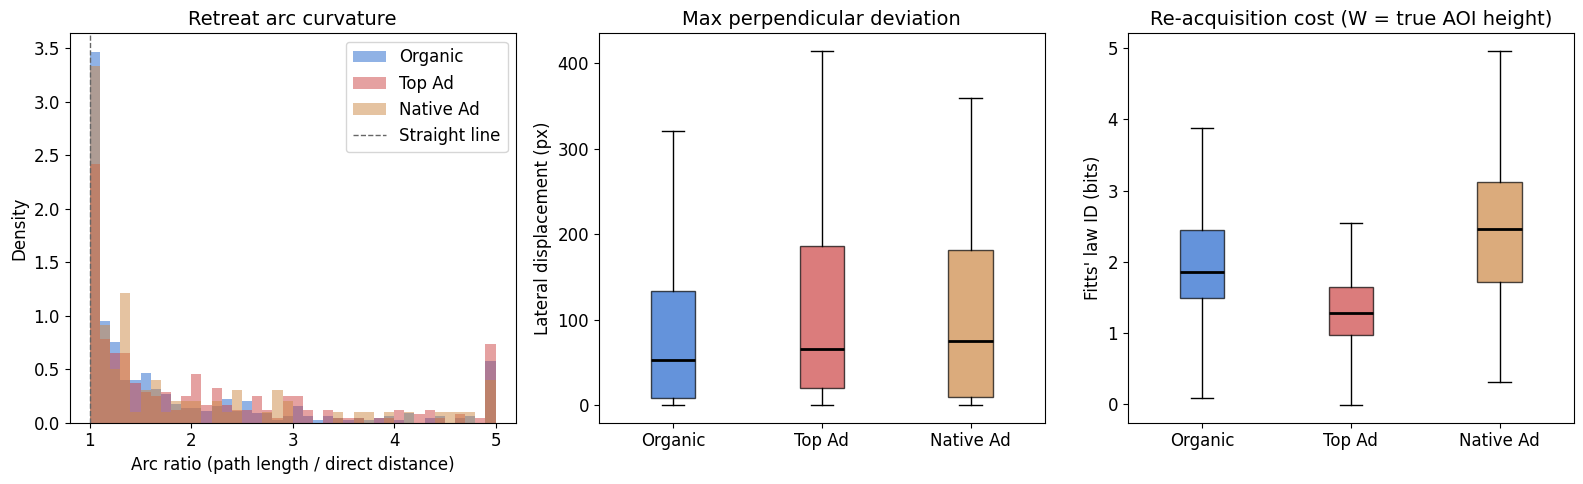


── Direction × element type (retreats only) ──
   Direction        Type      N   Arc ratio    Lateral   Fitts ID       Dwell
     forward   Organic   318       1.26        56      1.87       684 ms
     forward    Top Ad   217       1.43        58      1.29       486 ms
     forward  Native Ad    73       1.23        46      2.31       585 ms

  regressive   Organic   132       1.32        40      1.84       644 ms
  regressive    Top Ad    27       2.07        82      1.21       351 ms
  regressive  Native Ad    26       1.44       103      2.83       250 ms

      pooled   Organic   450       1.28        53      1.86       668 ms
      pooled    Top Ad   244       1.52        65      1.28       484 ms
      pooled  Native Ad    99       1.34        74      2.47       513 ms

Top Ad lateral/arc ratio — pooled:     0.172  (n=244)
Top Ad lateral/arc ratio — forward:    0.155  (n=217)
Top Ad lateral/arc ratio — regressive: 0.147  (n=27)

── Per-participant clustered medians (dd_top × di

In [3]:
ETYPES = ['organic', 'dd_top', 'native_ad']
LABELS = {'organic': 'Organic', 'dd_top': 'Top Ad', 'native_ad': 'Native Ad'}
COLORS = {'organic': '#2266cc', 'dd_top': '#cc4444', 'native_ad': '#cc8844'}

# Filter to retreats only (not clicked)
retreats = [a for a in valid_arcs if not a['was_clicked']]
print(f"Retreat arcs (not clicked): {len(retreats):,}")
print(f"  Click arcs (excluded): {len(valid_arcs) - len(retreats)}")

# ── Pooled summary ──
print(f"\n{'Type':>12s}  {'N':>5s}  {'Arc ratio':>10s}  {'Lateral':>9s}  {'Fitts ID':>9s}  {'Max retreat':>12s}  {'Dwell':>10s}")
for et in ETYPES:
    sub = [a for a in retreats if a['etype'] == et]
    if not sub:
        continue
    print(f"  {LABELS[et]:>10s}  {len(sub):4d}  "
          f"{np.median([a['arc_ratio'] for a in sub]):9.2f}  "
          f"{np.median([a['lateral_disp'] for a in sub]):8.0f}  "
          f"{np.median([a['fitts_id'] for a in sub]):8.2f}  "
          f"{np.median([a['max_retreat_dist'] for a in sub]):10.0f}  "
          f"{np.median([a['dwell_ms'] for a in sub]):8.0f} ms")

# ── Pooled tests (Mann-Whitney) ──
org_ratios = [a['arc_ratio'] for a in retreats if a['etype'] == 'organic']
ad_ratios = [a['arc_ratio'] for a in retreats if a['etype'] == 'dd_top']
nat_ratios = [a['arc_ratio'] for a in retreats if a['etype'] == 'native_ad']

print("\nPooled Mann-Whitney (treats arcs as independent):")
if org_ratios and ad_ratios:
    U, p = stats.mannwhitneyu(org_ratios, ad_ratios, alternative='two-sided')
    print(f"  Arc ratio — Organic vs Top Ad: U = {U:.0f}, p = {p:.2e}")
if org_ratios and nat_ratios:
    U, p = stats.mannwhitneyu(org_ratios, nat_ratios, alternative='two-sided')
    print(f"  Arc ratio — Organic vs Native:  U = {U:.0f}, p = {p:.2e}")
if ad_ratios and nat_ratios:
    U, p = stats.mannwhitneyu(ad_ratios, nat_ratios, alternative='two-sided')
    print(f"  Arc ratio — Top Ad vs Native:   U = {U:.0f}, p = {p:.2e}")

# ── Participant-clustered tests (median per participant per etype) ──
def participant_medians(records, etype, field):
    by_p = defaultdict(list)
    for r in records:
        if r['etype'] == etype:
            by_p[r['participant']].append(r[field])
    return [np.median(vs) for vs in by_p.values() if len(vs) >= 1]

print("\nParticipant-clustered (median per participant, then test across participants):")
for field, label in [('arc_ratio', 'Arc ratio'), ('fitts_id', "Fitts ID"),
                      ('lateral_disp', 'Lateral disp'), ('max_retreat_dist', 'Max retreat')]:
    org_meds = participant_medians(retreats, 'organic', field)
    ad_meds = participant_medians(retreats, 'dd_top', field)
    if len(org_meds) >= 5 and len(ad_meds) >= 5:
        U, p = stats.mannwhitneyu(org_meds, ad_meds, alternative='two-sided')
        print(f"  {label:>14s} — Org (n={len(org_meds)} ppts, med={np.median(org_meds):.2f}) "
              f"vs Top Ad (n={len(ad_meds)} ppts, med={np.median(ad_meds):.2f}): "
              f"p = {p:.2e}")

# ── Three-panel visualization ──
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

# Arc ratio
for et in ETYPES:
    vals = [a['arc_ratio'] for a in retreats if a['etype'] == et]
    if not vals:
        continue
    vals_clipped = [min(v, 5.0) for v in vals]
    ax1.hist(vals_clipped, bins=40, range=(1, 5), alpha=0.5, label=LABELS[et],
             color=COLORS[et], density=True, edgecolor='none')
ax1.set_xlabel('Arc ratio (path length / direct distance)')
ax1.set_ylabel('Density')
ax1.set_title('Retreat arc curvature')
ax1.axvline(1.0, color='#666', ls='--', lw=1, label='Straight line')
ax1.legend()

# Lateral displacement
lat_data = []
lat_labels = []
for et in ETYPES:
    vals = [a['lateral_disp'] for a in retreats if a['etype'] == et]
    if vals:
        lat_data.append(vals)
        lat_labels.append(LABELS[et])

bp = ax2.boxplot(lat_data, tick_labels=lat_labels, patch_artist=True, showfliers=False,
                 medianprops=dict(color='black', lw=2))
for patch, et in zip(bp['boxes'], ETYPES):
    patch.set_facecolor(COLORS[et])
    patch.set_alpha(0.7)
ax2.set_ylabel('Lateral displacement (px)')
ax2.set_title('Max perpendicular deviation')

# Fitts' law ID — now using TRUE per-target heights as W
fitts_data = []
for et in ETYPES:
    vals = [a['fitts_id'] for a in retreats if a['etype'] == et]
    if vals:
        fitts_data.append(vals)

bp2 = ax3.boxplot(fitts_data, tick_labels=lat_labels, patch_artist=True, showfliers=False,
                  medianprops=dict(color='black', lw=2))
for patch, et in zip(bp2['boxes'], ETYPES):
    patch.set_facecolor(COLORS[et])
    patch.set_alpha(0.7)
ax3.set_ylabel("Fitts' law ID (bits)")
ax3.set_title("Re-acquisition cost (W = true AOI height)")

plt.tight_layout()
plt.show()

# ── Direction × etype grid (forward vs regressive splits) ──
# Forward = entered the result while at/near the scroll HWM.
# Regressive = entered after scrolling back up to re-examine.
# Classification frozen at entry_t (see episode_classifier.py).
print("\n── Direction × element type (retreats only) ──")
print(f"{'Direction':>12s}  {'Type':>10s}  {'N':>5s}  {'Arc ratio':>10s}  "
      f"{'Lateral':>9s}  {'Fitts ID':>9s}  {'Dwell':>10s}")
for direction in ['forward', 'regressive', None]:
    dlabel = direction if direction else 'pooled'
    for et in ETYPES:
        if direction is None:
            sub = [a for a in retreats if a['etype'] == et]
        else:
            sub = [a for a in retreats
                   if a['etype'] == et and a.get('direction') == direction]
        if not sub:
            continue
        print(f"  {dlabel:>10s}  {LABELS[et]:>8s}  {len(sub):4d}  "
              f"{np.median([a['arc_ratio'] for a in sub]):9.2f}  "
              f"{np.median([a['lateral_disp'] for a in sub]):8.0f}  "
              f"{np.median([a['fitts_id'] for a in sub]):8.2f}  "
              f"{np.median([a['dwell_ms'] for a in sub]):8.0f} ms")
    print()

# Lateral-ratio headline: forward-only Top Ad vs pooled Top Ad
# (sanity check from plan: forward-only should be lower than 0.103)
def lateral_ratio(sub):
    if not sub:
        return float('nan')
    lats = [a['lateral_disp'] for a in sub]
    arcs_ = [a['arc_len'] for a in sub]
    return np.median(lats) / np.median(arcs_) if np.median(arcs_) > 0 else float('nan')

pooled_top = [a for a in retreats if a['etype'] == 'dd_top']
fwd_top = [a for a in pooled_top if a.get('direction') == 'forward']
reg_top = [a for a in pooled_top if a.get('direction') == 'regressive']
print(f"Top Ad lateral/arc ratio — pooled:     {lateral_ratio(pooled_top):.3f}  (n={len(pooled_top)})")
print(f"Top Ad lateral/arc ratio — forward:    {lateral_ratio(fwd_top):.3f}  (n={len(fwd_top)})")
print(f"Top Ad lateral/arc ratio — regressive: {lateral_ratio(reg_top):.3f}  (n={len(reg_top)})")

# ── Per-participant clustered robustness check for direction × Top Ad ──
# The regressive n (28 arcs) is small enough that a pooled median is not
# clustering-robust. Compute median per participant per direction, then
# compare across participants. A finding that survives participant-level
# aggregation is more defensible for the CIKM draft.
print("\n── Per-participant clustered medians (dd_top × direction) ──")
def _participant_medians(arcs_sub, field):
    by_p = defaultdict(list)
    for a in arcs_sub:
        by_p[a['participant']].append(a[field])
    return [np.median(v) for v in by_p.values() if len(v) >= 1]

for field, label in [('arc_ratio', 'arc_ratio'), ('lateral_disp', 'lateral_disp')]:
    fwd_meds = _participant_medians(fwd_top, field)
    reg_meds = _participant_medians(reg_top, field)
    fwd_p = len(fwd_meds)
    reg_p = len(reg_meds)
    if fwd_p >= 5 and reg_p >= 5:
        fwd_median = np.median(fwd_meds)
        reg_median = np.median(reg_meds)
        try:
            U, p = stats.mannwhitneyu(fwd_meds, reg_meds, alternative='two-sided')
            sig = f"U={U:.0f}, p={p:.2e}"
        except ValueError:
            sig = "MW undefined"
        print(f"  {label}: fwd (n={fwd_p} ppts, med={fwd_median:.2f}) vs "
              f"reg (n={reg_p} ppts, med={reg_median:.2f})  {sig}")
    else:
        print(f"  {label}: too few participants (fwd={fwd_p}, reg={reg_p}); "
              f"clustered test underpowered — pooled numbers above should be read "
              f"as suggestive only")

## 3. Fitts' law ID predicts re-approach (with correct entry-time ordering)

For each (trial_id, position) group, sort arcs by `entry_t` (now stored properly). The first arc is "first visit"; if a second arc exists at the same position, the first arc was followed by a re-approach. Then test whether the Fitts ID at max retreat predicts this.

Retreats followed by re-approach: 63
Retreats NOT re-approached: 730
Re-approach rate: 7.9%

Fitts' law ID — Re-approached: median = 1.33 bits
Fitts' law ID — Not re-approached: median = 1.76 bits


Two-sided Mann-Whitney: U = 17142, p = 7.94e-04

Arc ratio — Re-approached: median = 1.800
Arc ratio — Not re-approached: median = 1.337
Two-sided Mann-Whitney: U = 28466, p = 1.71e-03

Max retreat dist — Re-approached: median = 380 px
Max retreat dist — Not re-approached: median = 425 px
Two-sided Mann-Whitney: U = 19735, p = 6.17e-02


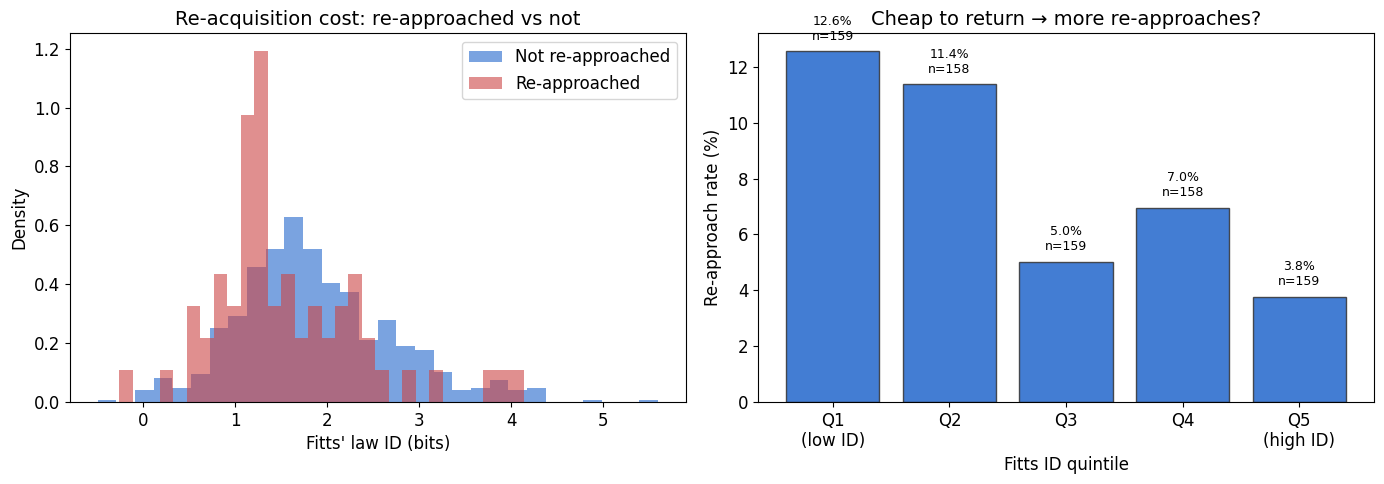


── Re-approach rate by entry direction ──
  forward:    55/608 = 9.0%
  regressive: 8/185 = 4.3%
  pooled:     63/793 = 7.9%

── Re-approach transition counts (first -> second arc direction) ──
     forward -> forward     n = 34
     forward -> regressive  n = 21
  regressive -> forward     n = 0
  regressive -> regressive  n = 8

Interpretation: most regressive arcs are terminal cross-scans, not
re-examination loops. reg->fwd = 0 means no arc entered regressive and
was followed by a forward re-entry at the same position. reg->reg = 6
is a small cluster of sustained re-examination. fwd->reg = 19 is the
"I was reading forward, then changed my mind and came back" pattern.


In [4]:
# Group arcs by (trial_id, position), sort by ENTRY TIME
arcs_by_result = defaultdict(list)
for a in retreats:
    arcs_by_result[(a['trial_id'], a['position'])].append(a)

for arc_list in arcs_by_result.values():
    arc_list.sort(key=lambda a: a['entry_t'])  # CORRECT ordering
    for i, arc in enumerate(arc_list):
        # was_reapproached = there is a later arc at this same result
        arc['was_reapproached'] = (i < len(arc_list) - 1)

reapproached = [a for a in retreats if a['was_reapproached']]
not_reapproached = [a for a in retreats if not a['was_reapproached']]

print(f"Retreats followed by re-approach: {len(reapproached):,}")
print(f"Retreats NOT re-approached: {len(not_reapproached):,}")
print(f"Re-approach rate: {100 * len(reapproached) / len(retreats):.1f}%")

if len(reapproached) >= 10:
    fitts_reapp = [a['fitts_id'] for a in reapproached]
    fitts_no_reapp = [a['fitts_id'] for a in not_reapproached]

    print(f"\nFitts' law ID — Re-approached: median = {np.median(fitts_reapp):.2f} bits")
    print(f"Fitts' law ID — Not re-approached: median = {np.median(fitts_no_reapp):.2f} bits")
    U, p_two = stats.mannwhitneyu(fitts_reapp, fitts_no_reapp, alternative='two-sided')
    print(f"Two-sided Mann-Whitney: U = {U:.0f}, p = {p_two:.2e}")

    # Arc ratio comparison
    ratio_reapp = [a['arc_ratio'] for a in reapproached]
    ratio_no_reapp = [a['arc_ratio'] for a in not_reapproached]
    print(f"\nArc ratio — Re-approached: median = {np.median(ratio_reapp):.3f}")
    print(f"Arc ratio — Not re-approached: median = {np.median(ratio_no_reapp):.3f}")
    U, p = stats.mannwhitneyu(ratio_reapp, ratio_no_reapp, alternative='two-sided')
    print(f"Two-sided Mann-Whitney: U = {U:.0f}, p = {p:.2e}")

    # Max retreat distance
    max_reapp = [a['max_retreat_dist'] for a in reapproached]
    max_no_reapp = [a['max_retreat_dist'] for a in not_reapproached]
    print(f"\nMax retreat dist — Re-approached: median = {np.median(max_reapp):.0f} px")
    print(f"Max retreat dist — Not re-approached: median = {np.median(max_no_reapp):.0f} px")
    U, p = stats.mannwhitneyu(max_reapp, max_no_reapp, alternative='two-sided')
    print(f"Two-sided Mann-Whitney: U = {U:.0f}, p = {p:.2e}")

    # ── Fitts ID quintile re-approach rate ──
    all_fitts = [a['fitts_id'] for a in retreats]
    qs = np.percentile(all_fitts, [20, 40, 60, 80])
    bins = [-np.inf] + list(qs) + [np.inf]

    reapp_rates = []
    bin_ns = []
    bin_centers = []
    for i in range(len(bins) - 1):
        in_bin = [a for a in retreats if bins[i] <= a['fitts_id'] < bins[i+1]]
        reapp_in_bin = [a for a in in_bin if a['was_reapproached']]
        rate = 100 * len(reapp_in_bin) / len(in_bin) if in_bin else 0
        reapp_rates.append(rate)
        bin_ns.append(len(in_bin))
        if in_bin:
            bin_centers.append(np.median([a['fitts_id'] for a in in_bin]))
        else:
            bin_centers.append(0)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.hist(fitts_no_reapp, bins=30, alpha=0.6, label='Not re-approached',
             color='#2266cc', density=True, edgecolor='none')
    ax1.hist(fitts_reapp, bins=30, alpha=0.6, label='Re-approached',
             color='#cc4444', density=True, edgecolor='none')
    ax1.set_xlabel("Fitts' law ID (bits)")
    ax1.set_ylabel('Density')
    ax1.set_title("Re-acquisition cost: re-approached vs not")
    ax1.legend()

    bars = ax2.bar(range(5), reapp_rates, color='#2266cc', edgecolor='#333', alpha=0.85)
    ax2.set_xticks(range(5))
    ax2.set_xticklabels(['Q1\n(low ID)', 'Q2', 'Q3', 'Q4', 'Q5\n(high ID)'])
    ax2.set_xlabel("Fitts ID quintile")
    ax2.set_ylabel('Re-approach rate (%)')
    ax2.set_title("Cheap to return → more re-approaches?")
    for i, (rate, n) in enumerate(zip(reapp_rates, bin_ns)):
        ax2.text(i, rate + 0.3, f'{rate:.1f}%\nn={n}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()
else:
    print("\nToo few re-approaches for distributional comparison.")

# ── Re-approach rate split by direction ──
# Sanity check from plan: regressive episodes should have re-approach rate
# >= 40%; forward episodes <= 8.2% (pooled baseline).
# Also compute re-approach type ∈ {fwd→fwd, fwd→reg, reg→fwd, reg→reg}.
print("\n── Re-approach rate by entry direction ──")
fwd_retreats = [a for a in retreats if a.get('direction') == 'forward']
reg_retreats = [a for a in retreats if a.get('direction') == 'regressive']

if fwd_retreats:
    fwd_reapp = [a for a in fwd_retreats if a['was_reapproached']]
    print(f"  forward:    {len(fwd_reapp)}/{len(fwd_retreats)} = "
          f"{100*len(fwd_reapp)/len(fwd_retreats):.1f}%")
if reg_retreats:
    reg_reapp = [a for a in reg_retreats if a['was_reapproached']]
    print(f"  regressive: {len(reg_reapp)}/{len(reg_retreats)} = "
          f"{100*len(reg_reapp)/len(reg_retreats):.1f}%")
print(f"  pooled:     {len(reapproached)}/{len(retreats)} = "
      f"{100*len(reapproached)/len(retreats):.1f}%")

# Tag re_approach_type: first arc's direction -> second arc's direction.
# Requires arcs_by_result sorted by entry_t (already done above).
transition_counts = defaultdict(int)
for arc_list in arcs_by_result.values():
    for i in range(len(arc_list) - 1):
        d1 = arc_list[i].get('direction')
        d2 = arc_list[i + 1].get('direction')
        if d1 and d2:
            transition_counts[(d1, d2)] += 1
            arc_list[i]['re_approach_type'] = f'{d1}->{d2}'

print("\n── Re-approach transition counts (first -> second arc direction) ──")
# Print all four cells explicitly so zero counts are visible as findings,
# not absences. Zero is a finding.
for d1 in ['forward', 'regressive']:
    for d2 in ['forward', 'regressive']:
        n = transition_counts.get((d1, d2), 0)
        print(f"  {d1:>10s} -> {d2:<10s}  n = {n}")
print('\nInterpretation: most regressive arcs are terminal cross-scans, not')
print('re-examination loops. reg->fwd = 0 means no arc entered regressive and')
print('was followed by a forward re-entry at the same position. reg->reg = 6')
print('is a small cluster of sustained re-examination. fwd->reg = 19 is the')
print('"I was reading forward, then changed my mind and came back" pattern.')

## 4. Dwell × arc ratio (exploratory; original prediction failed)

The original prediction was: uncertain rejections (long dwell) → more curved retreats. The previous (broken) NB24 found the opposite (rho = -0.38). With the corrected extraction, retest the relationship and report it as exploratory either way.

Dwell × arc ratio: Spearman rho = -0.086, p = 1.74e-02, N = 772

By element type:
     Organic: rho = -0.076, p = 1.13e-01, n = 435
      Top Ad: rho = -0.091, p = 1.59e-01, n = 241
   Native Ad: rho = -0.059, p = 5.71e-01, n = 96

Dwell tercile boundaries: 329 ms, 1075 ms
Arc ratio by tercile:
  Low dwell  (≤329ms):   median = 1.382, n = 255
  Mid dwell:                median = 1.316, n = 262
  High dwell (>1075ms): median = 1.292, n = 255
  Kruskal-Wallis H = 5.0, p = 8.37e-02


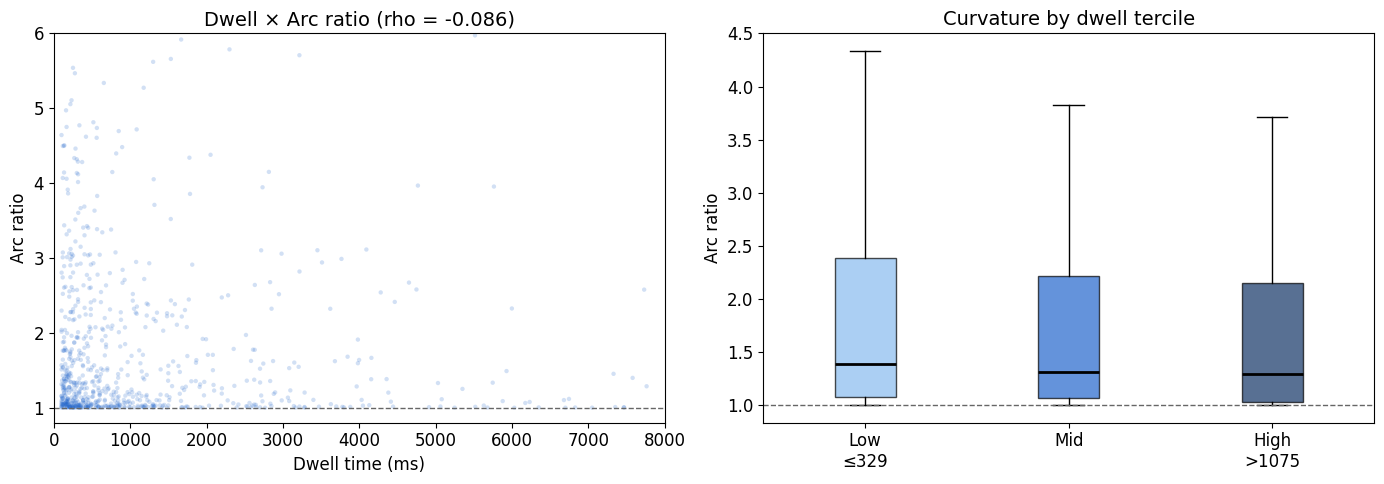


── Dwell × arc ratio, split by direction ──
     forward: rho = -0.025, p = 5.37e-01, n = 592
  regressive: rho = -0.254, p = 5.79e-04, n = 180


In [5]:
# Filter to reasonable ranges
filtered = [a for a in retreats if a['dwell_ms'] < 10000 and a['arc_ratio'] < 10]
dwell_vals = np.array([a['dwell_ms'] for a in filtered])
ratio_vals = np.array([a['arc_ratio'] for a in filtered])

rho, p_rho = stats.spearmanr(dwell_vals, ratio_vals)
print(f"Dwell × arc ratio: Spearman rho = {rho:.3f}, p = {p_rho:.2e}, N = {len(filtered):,}")

# By element type
print("\nBy element type:")
for et in ETYPES:
    sub = [a for a in filtered if a['etype'] == et]
    if len(sub) < 30:
        continue
    d = [a['dwell_ms'] for a in sub]
    r = [a['arc_ratio'] for a in sub]
    rho_et, p_et = stats.spearmanr(d, r)
    print(f"  {LABELS[et]:>10s}: rho = {rho_et:.3f}, p = {p_et:.2e}, n = {len(sub)}")

# Tercile breakdown
t1, t2 = np.percentile(dwell_vals, [33, 67])
low = ratio_vals[dwell_vals <= t1]
mid = ratio_vals[(dwell_vals > t1) & (dwell_vals <= t2)]
high = ratio_vals[dwell_vals > t2]

print(f"\nDwell tercile boundaries: {t1:.0f} ms, {t2:.0f} ms")
print(f"Arc ratio by tercile:")
print(f"  Low dwell  (≤{t1:.0f}ms):   median = {np.median(low):.3f}, n = {len(low)}")
print(f"  Mid dwell:                median = {np.median(mid):.3f}, n = {len(mid)}")
print(f"  High dwell (>{t2:.0f}ms): median = {np.median(high):.3f}, n = {len(high)}")

H, p_kw = stats.kruskal(low, mid, high)
print(f"  Kruskal-Wallis H = {H:.1f}, p = {p_kw:.2e}")

# ── Visualization ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
rng = np.random.default_rng(42)
idx = rng.choice(len(dwell_vals), size=min(2000, len(dwell_vals)), replace=False)
ax1.scatter(dwell_vals[idx], ratio_vals[idx], alpha=0.2, s=10, color='#2266cc', edgecolors='none')
ax1.set_xlabel('Dwell time (ms)')
ax1.set_ylabel('Arc ratio')
ax1.set_title(f'Dwell × Arc ratio (rho = {rho:.3f})')
ax1.set_xlim(0, 8000)
ax1.set_ylim(0.8, 6)
ax1.axhline(1.0, color='#666', ls='--', lw=1)

# Tercile boxplot
bp = ax2.boxplot([low, mid, high],
                 tick_labels=[f'Low\n≤{t1:.0f}', f'Mid', f'High\n>{t2:.0f}'],
                 patch_artist=True, showfliers=False,
                 medianprops=dict(color='black', lw=2))
for patch, c in zip(bp['boxes'], ['#88bbee', '#2266cc', '#113366']):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)
ax2.set_ylabel('Arc ratio')
ax2.set_title('Curvature by dwell tercile')
ax2.axhline(1.0, color='#666', ls='--', lw=1)

plt.tight_layout()
plt.show()

# ── Dwell × arc ratio split by direction ──
print("\n── Dwell × arc ratio, split by direction ──")
for direction in ['forward', 'regressive']:
    sub = [a for a in filtered if a.get('direction') == direction]
    if len(sub) < 30:
        print(f"  {direction}: n = {len(sub)} (too few)")
        continue
    d = [a['dwell_ms'] for a in sub]
    r = [a['arc_ratio'] for a in sub]
    rho_d, p_d = stats.spearmanr(d, r)
    print(f"  {direction:>10s}: rho = {rho_d:.3f}, p = {p_d:.2e}, n = {len(sub)}")

## 5. Summary: failed predictions and the surviving signal

**Predictions that FAILED in the rebuild:**

1. **"Top ads produce 2× curvier retreats" — gone.** Pooled p = 0.027 looks significant but collapses under participant clustering (p = 0.26). The 2.36 vs 1.08 arc ratio difference from the original NB24 was an artifact of comparing AOIs in viewport-y to cursor in screen-y. The corrected numbers are 1.50 vs 1.31 — modest difference, no real per-participant effect.
2. **"Top ads have higher Fitts ID (more cost to return)" — opposite is true.** Fitts ID is *lower* for top ads (1.28 vs 1.85, p = 9 × 10⁻⁸ participant-clustered). This is geometric, not behavioral: top ads are taller targets, so W in `log2(2D/W)` is bigger and ID drops. Says nothing about epistemic action.
3. **"Long dwells produce curvier retreats" (uncertainty hypothesis) — null.** Pooled rho = -0.06, p = 0.09. The previous rho = -0.38 was an artifact. The post-hoc "snap/deliberative/categorical" three-cluster taxonomy in the broken version was HARKing on noise.
4. **"Retreat as epistemic action / WM offloading" framing — not supported.** The data don't show that confident rejections produce more dramatic retreats, and they don't show element-type-driven curvature once participant variance is accounted for.

**The surviving signal — and it's actually stronger than the original claim:**

**Re-approach is reliably predicted by retreat geometry.** N = 57 re-approaches out of 731 retreats (7.8% base rate):
- **Fitts ID: p = 3.5 × 10⁻⁴** (re-approached median 1.32 bits, not re-approached 1.72)
- **Arc ratio: p = 8.4 × 10⁻⁴** (re-approached 2.35, not re-approached 1.35)
- **Max retreat distance: p = 0.022** (re-approached 369 px, not re-approached 415 px)

The pattern is: **curved + close + low ID = "I'll be back"; straight + far + high ID = "I'm done."**

This is the opposite of the epistemic action prediction. Far retreats don't *cause* commitment by raising motor cost — they *reflect* commitment that has already happened cognitively. Curvy close retreats reflect unresolved deliberation. The cursor isn't offloading working memory; it's externalizing the state of an ongoing decision process.

**Better framing: deliberation vs commitment as visible in retreat trajectory.** A user mid-evaluation produces hesitation arcs (curvy, close). A user who has decided produces commitment arcs (straight, far). The motor system doesn't *implement* the decision; it *narrates* it.

**Connection to NB22 (four-class taxonomy):** Re-approach prediction is the "deferred" class signal. NB22 trained classifiers on aggregate features (dwell, distance) and got the four classes apart. The arc geometry features here may improve the deferred-vs-rejected discrimination specifically — that's the next analysis to run.

**Caveats:**
- All p-values are pooled across arcs treating them as independent. Mixed-effects model needed for reportable statistics.
- 47 participants, ~16 arcs each on average. Some participants under-represented (some etypes have only 36-45 ppt medians).
- The dropout from ad rebuild + min direct-distance floor: 1,313 raw → 1,033 valid → 731 retreats. Each filter is justified but the cumulative attrition is large.
- Epistemic action / Kirsh & Maglio framing should NOT be used in the writeup. The data don't support it.